In [1]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import sys, os
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

In [2]:
import time
from LandMPC.MPCLandControl import MPCLandControl
from src.rocket import Rocket, perturb_rocket
from src.pos_rocket_vis import *

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir,"rocket.yaml")

# Rocket setup
Ts  = 1/20
rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
rocket.mass = 1.7 # Do not change!!!

# Visualization setup
vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 0.1

In [3]:
sim_time = 5.0 # simulation length in seconds
x0 = np.array([0, 0, 0, 0, 0, np.deg2rad(30), 0, 0, 0, 3, 2, 10]) # w, phi, v, p
x_ref = np.array([0.]*9 + [1., 0., 3.])
xs, us = rocket.trim(x_ref)
print("Linearization around a steady state:")
print("x_ref = ", x_ref)
print("xs = ", xs)
print("us = ", us)
A, B = rocket.linearize(xs, us)

# MPC parameters
H = 4.0
# Merge four linear mpc
mpc = MPCLandControl().new_controller(rocket, Ts, H, x_ref=x_ref)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Linearization around a steady state:
x_ref =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 3.]
xs =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 3.]
us =  [ 0.          0.         56.66666667  0.        ]


Simulating time 0.00

 State alpha violation: 0.26 > 0.17, 
 State alpha violation: 0.39 > 0.17, 
 State alpha violation: 0.51 > 0.17, 
 State beta violation: -0.22 < -0.17, 
 State alpha violation: 0.61 > 0.17, 
 State beta violation: -0.28 < -0.17, 
 State alpha violation: 0.68 > 0.17, 
 State beta violation: -0.34 < -0.17, 
 State alpha violation: 0.73 > 0.17, 
 State beta violation: -0.41 < -0.17, 
 State alpha violation: 0.75 > 0.17, 
 State beta violation: -0.47 < -0.17, 
 State alpha violation: 0.74 > 0.17, 
 State beta violation: -0.53 < -0.17, 
 State alpha violation: 0.68 > 0.17, 
 State beta violation: -0.58 < -0.17, 
 State alpha violation: 0.59 > 0.17, 
 State beta violation: -0.60 < -0.17, 
 State alpha violation: 0.43 > 0.17, 
 State beta violation: -0.58 < -0.17, 
 State alpha violation: 0.23 > 0.17, 
 State beta violation: -0.51 < -0.17, 
 State beta violation: -0.38 < -0.17, 
 State alpha violation: -0.24 < -0.17, 
 State beta violation: -0.23 < -0.17, 
 State alpha v

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', interval=500, max=99), IntSlider(va…

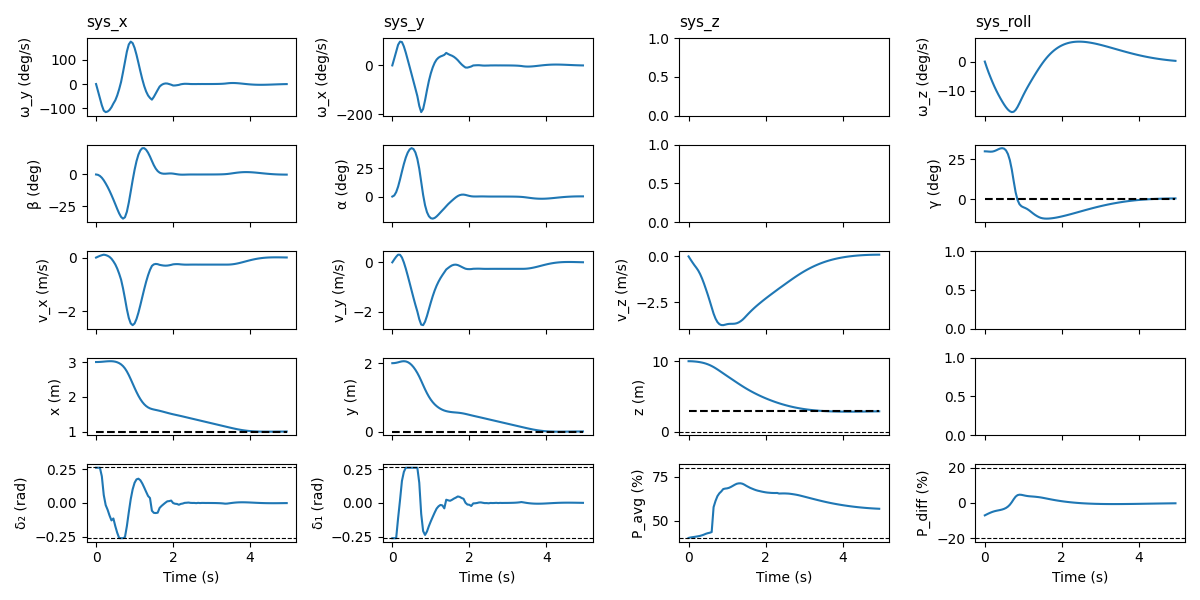

In [4]:
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol = rocket.simulate_land(mpc, sim_time, H, x0)
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl, T_ol=t_ol[...,:-1], X_ol=x_ol, U_ol=u_ol)
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, xs)